In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import sys 

os.environ["DISPLAY"]="localhost:10.0"



In [5]:
a = [-3,-6,6,-1]

print(np.maximum(a, 0))

[0 0 6 0]


In [3]:
EMINDR2_D = np.random.uniform(35e-6, 2*(67e-6))
EMINDR2_W = np.random.uniform(EMINDR2_D/2, 68e-6)

print(EMINDR2_W)
print(EMINDR2_D)

if(EMINDR2_D/EMINDR2_W < 2):
    print("satisfied")

6.790470691264693e-05
6.490374508524045e-05
satisfied


In [2]:
from keysight.ads import de
from keysight.ads.de import db_uu as db
from keysight.edatoolbox import ads
import keysight.pwdatatools as pwdt
import keysight.ads.dataset as dataset


Could not create collator: 4


In [25]:
workspace_path = "/home/jychung/ADS_project/test"
workspace = de.open_workspace(workspace_path)

In [4]:
library_name = "tutorial1_lib"
library_path = workspace.path / library_name

In [26]:
de.create_new_library(library_name, library_path)

"Library ""tutorial1_lib""",0 cells,"open, writable","path ""/home/jychung/ADS_project/test/tutorial1_lib"""


In [58]:
workspace.add_library(library_name, library_path, de.LibraryMode.SHARED)

In [5]:
lib = workspace.open_library(library_name, library_path, de.LibraryMode.SHARED)


In [6]:
win_PDK = "WIN_NP15_00_DESIGN_KIT:"

In [26]:
# design = db.open_design("tutorial1_lib:python_schematic:schematic", db.DesignMode.WRITE)
design = db.open_design("tutorial1_lib:sample_gan_25GHz_twostage_ppo:schematic", db.DesignMode.APPEND)
print(type(design))
# APPEND : 만들어놓은 디자인을 수정
# WRITE : 만들어놓은 디자인 초기화하고 열기 ==> WRITE로 열면 schematic 만든거 지워져서 isntance 인식이 안됨
# READ_ONLY : 읽기만 가능


<class 'keysight.ads.de.db_uu._design.Design'>


In [27]:
# TR1 = design.add_instance("WIN_NP15_00_DESIGN_KIT:NP1500_CPW:symbol", (0,0))
netlist = design.generate_netlist()
print(netlist)

; Top Design: "tutorial1_lib:sample_gan_25GHz_twostage_ppo:schematic"
; Netlisted using Hierarchy Policy: "Standard"

Options ResourceUsage=yes UseNutmegFormat=no EnableOptim=no TopDesignName="tutorial1_lib:sample_gan_25GHz_twostage_ppo:schematic" DcopOutputNodeVoltages=yes DcopOutputPinCurrents=yes DcopOutputAllSweepPoints=no DcopOutputDcopType=0
NP1500_Corner=0
NP1500_CornerTFR=0
NP1500_CornerMSR=0
NP1500_CornerMIM=0
NP1500_Met2T=4 um
NP1500_Thickness=100 um
#include "/home/jychung/Compound_semi_pdk/WIN_NP15_00_DESIGN_KIT//circuit/models/common.net"
#include "/home/jychung/Compound_semi_pdk/WIN_NP15_00_DESIGN_KIT//circuit/models/techonology.net"
NP1500_CPW:CPW_1  N__25 N__11 N__1 N__4 N__0 NOF=4 UGW=50.0 um TEMP=25 Th_N=0 
S_Param:SP1 CalcS=yes CalcY=no CalcZ=no GroupDelayAperture=1e-4 FreqConversion=no FreqConversionPort=1 StatusLevel=2 CalcNoise=yes SortNoise=0 BandwidthForNoise=1.0 Hz DevOpPtLevel=0 SPSS_WSP=yes \
SweepVar="freq" SweepPlan="SP1_stim" OutputPlan="SP1_Output" 

Swee

In [30]:
output_dir = "/home/jychung/ADS_project/test/" 

simulator = ads.CircuitSimulator()

simulator.run_netlist(netlist, output_dir)

790
8000000000.0
-9.063226464215813


/TOOLS/KEYSIGHT/tools/python/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/TOOLS/KEYSIGHT/tools/python/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


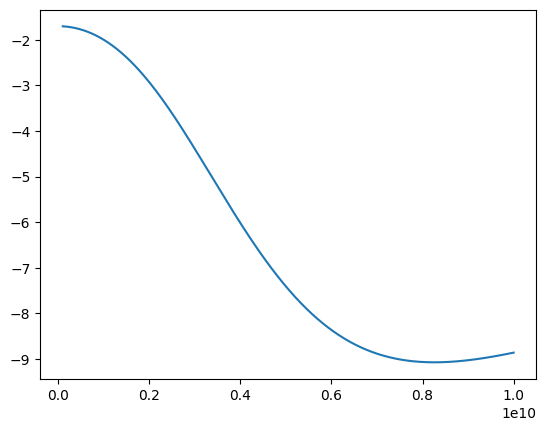

In [ ]:
output_data = dataset.open(output_dir+"MS_python.ds")

dtatf = output_data["SP1.SP"].to_dataframe().reset_index()

f = np.asarray(dtatf["freq"], dtype=float)

idx_target_freq = np.where((f == 8.0e9))[0][0]
print(idx_target_freq)
print(f[idx_target_freq])
# print(f[idx_target_freq])
plt.plot(dtatf["freq"], 20*np.log10(dtatf["S[1,1]"]))

print(20*np.log10(abs(dtatf["S[1,1]"][idx_target_freq])))

# s11 = np.asarray(dtatf["nf[1]"], dtype=float)
# print(s11)

In [66]:
design.save_design()


In [67]:
lib.close()

In [32]:
workspace.close()

RuntimeError: The workspace "/home/jychung/ADS_project/test" is not open.